# **Challenge Técnico (Core)**
**Objetivo:** Los estudiantes deberán participar en una competencia de Kaggle, realizar un análisis completo del dataset, entrenar y evaluar al menos cinco modelos diferentes, y realizar un benchmark para comparar su rendimiento. El resultado final debe ser subido a GitHub.

### **1. Registro en Kaggle y Elección de Competencia:**

- Los estudiantes deben registrarse en Kaggle si no lo han hecho aún.
- Elegir una competencia activa que esté alineada con los conocimientos y técnicas aprendidas (por ejemplo, una competencia de clasificación o regresión).

**Los estudiantes deben registrarse en Kaggle si no lo han hecho aún.**



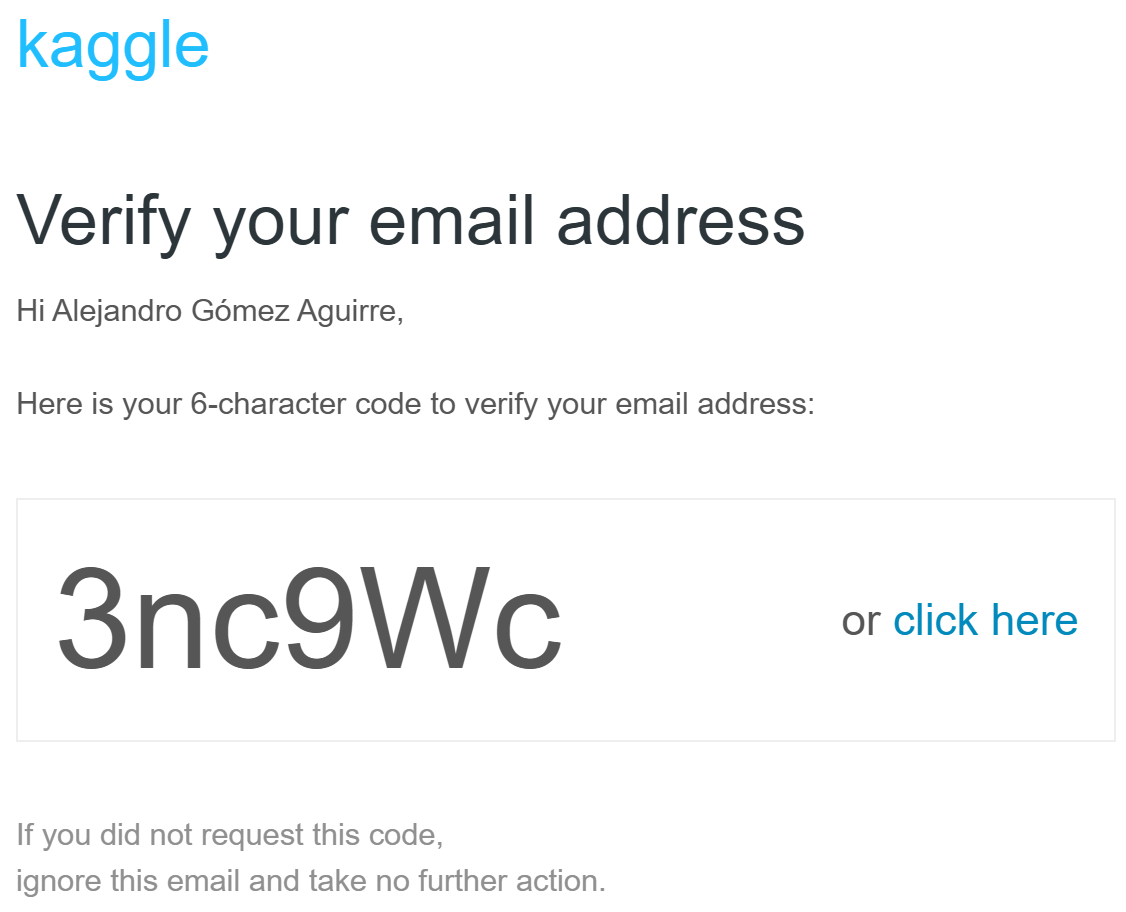

In [67]:
# mostrar imagen de registro en KAGGLE
from IPython.display import Image
Image('Registro Kaggle.png')

**Elegir una competencia activa que esté alineada con los conocimientos y técnicas aprendidas (por ejemplo, una competencia de clasificación o regresión).**

Proyecto Kaggle: House Prices - Advanced Regression Techniques

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

### **2. Carga y Exploración Inicial de Datos:**

- Descargar el dataset de la competencia.
- Realizar una exploración inicial para entender la estructura del dataset y las características disponibles.
- Identificar y documentar valores faltantes y outliers.

In [68]:
# Importamos librerias necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


In [69]:
# Importamos los datos de Train y Test
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
#sample = pd.read_csv('sample_submission.csv')

In [70]:
# Imprime la cantidad de folas y columnas de los dataframes
print(train.shape)
print(test.shape)
#print(sample.shape)

(1460, 81)
(1459, 80)


In [71]:
train.columns.values

array(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'Pav

In [72]:
test.columns.values

array(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'Pav

### **Observación:**
Se revisa y se aprecia que por ser una competencia, el dataset de Test no tiene Target, por lo que para el caso de este CORE, sólo se trabajará con el archivo de Train.

**Realizar una exploración inicial para entender la estructura del dataset y las características disponibles.**

In [73]:
# Desplegamos la estructura del Dataframe
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [74]:
# Validamos la existencia de valores nulos, desplegando sólo las columnas que tienen nulos
train.isnull().sum()[train.isnull().sum() > 0]


,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


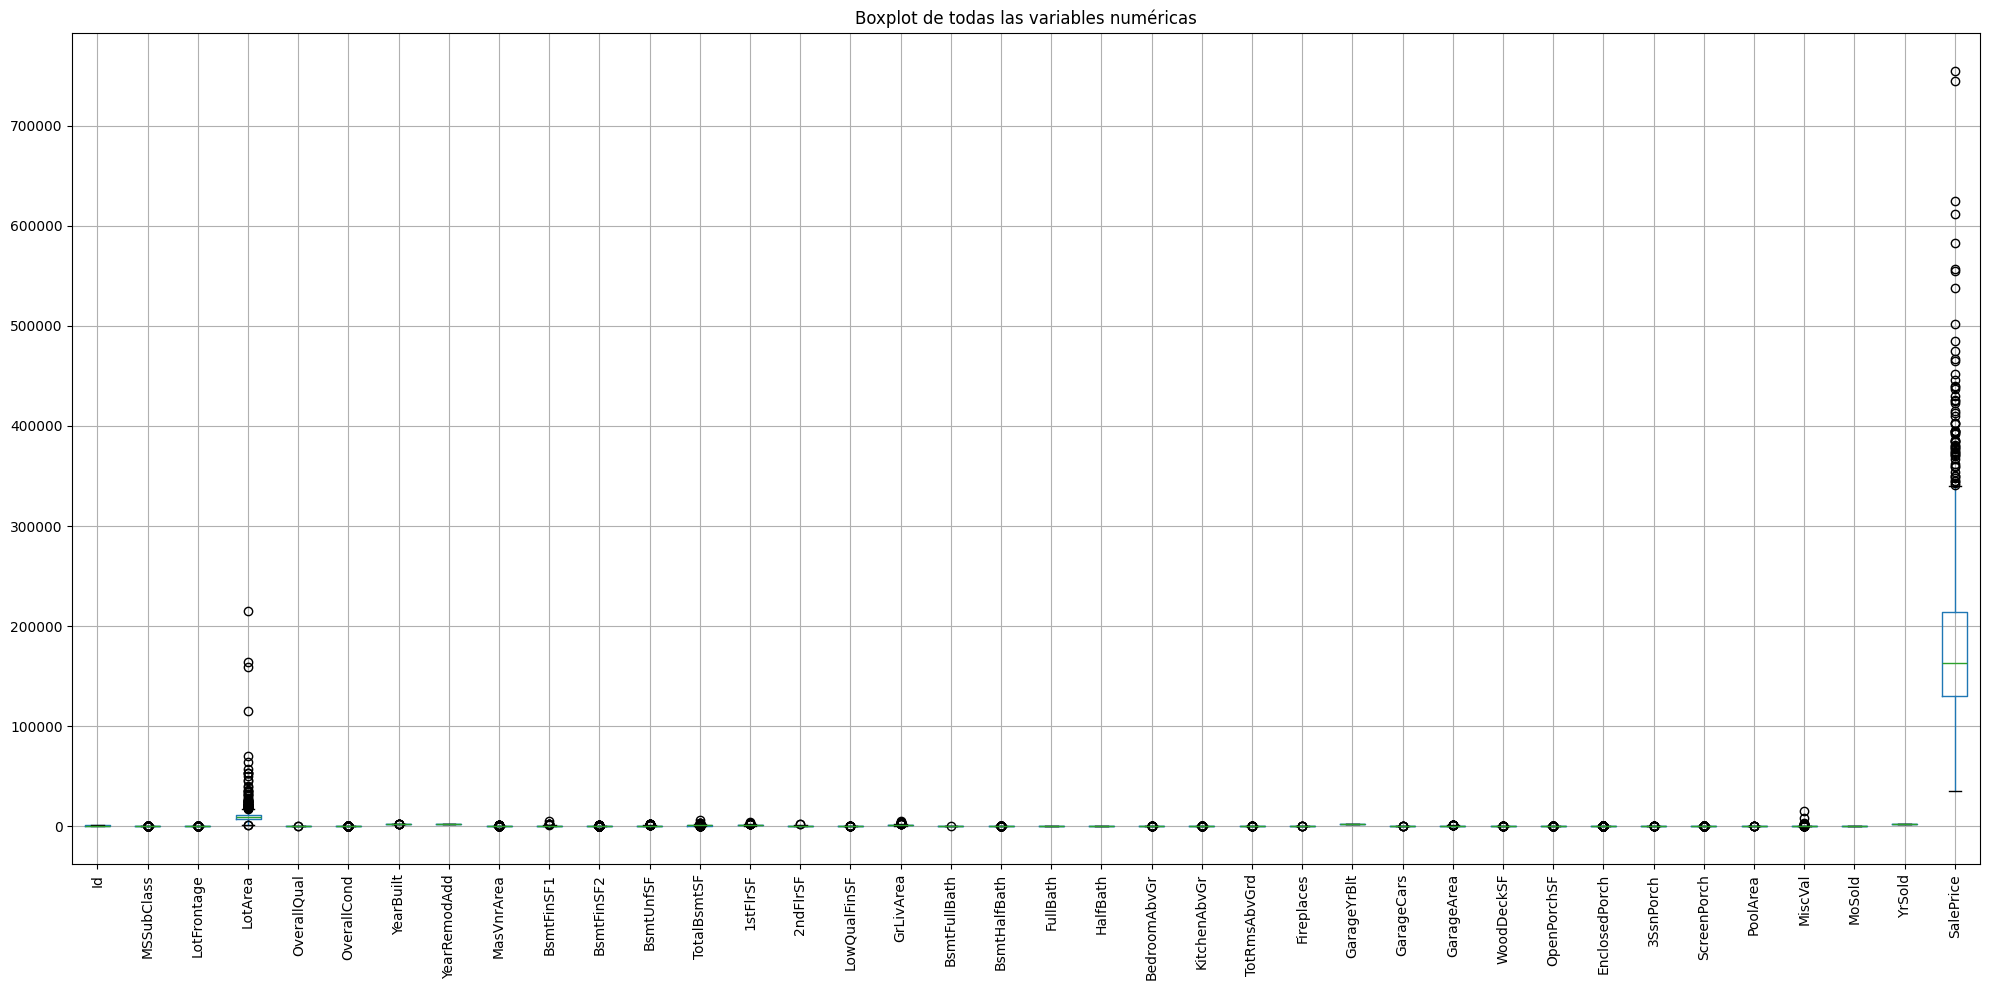

In [75]:
# Hacemos un boxplot con todas las variables numéricas para ver datos outliers
plt.figure(figsize=(20,10))
train.boxplot()
plt.title('Boxplot de todas las variables numéricas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Vemos  que las columnas LotArea y SalePrice tienen muchos datos outliers y muy marcados. Estos casos los estudiaremos para imputar o eliminar registros.

### **3. Análisis Exploratorio de Datos (EDA):**

- Calcular estadísticas descriptivas básicas.
- Crear visualizaciones para entender la distribución de las variables y sus relaciones.
- Detectar y tratar valores faltantes y outliers.

**Calcular estadísticas descriptivas básicas.**

In [76]:
# Utilizamos Describe para obtener la estadística de las variables
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Crear visualizaciones para entender la distribución de las variables y sus relaciones.**

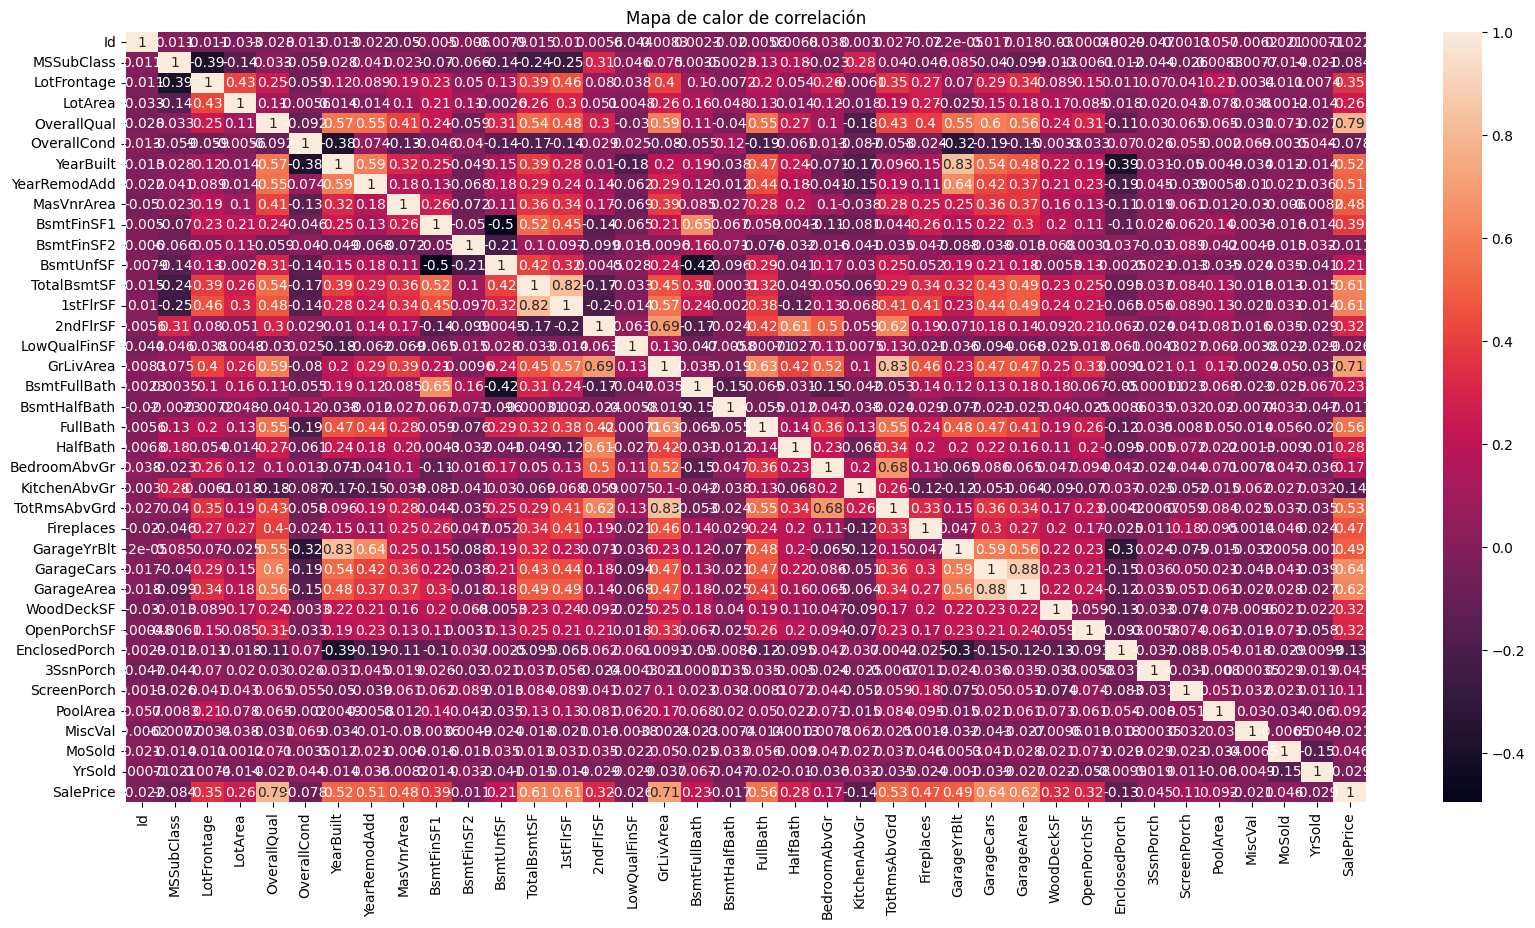

In [77]:
# mapa de calor para variables numericas
plt.figure(figsize=(20,10))
sns.heatmap(train.select_dtypes(include=np.number).corr(), annot=True)
plt.title('Mapa de calor de correlación')
plt.show()

**Detectar y tratar valores faltantes y outliers.**

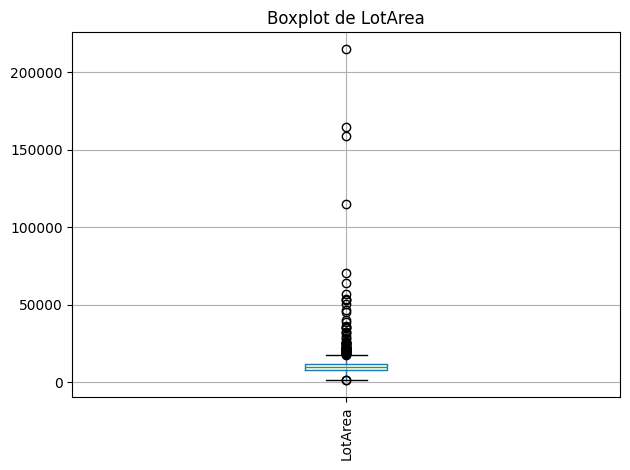

,LotArea
count,1460.000000
mean,10516.828082
std,9981.264932
min,1300.000000
25%,7553.500000
50%,9478.500000
75%,11601.500000
max,215245.000000


In [78]:
# En el grafico boxplot vimos 2 columnas con datos outliers y revisaremos ambas en detalle
# Análisis de LotArea

train.boxplot(column=['LotArea'])
plt.title('Boxplot de LotArea')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

train["LotArea"].describe()


In [79]:
# Calculamos el IQR y obtenemos el largo del bigote superior de LotArea
Q1 = train["LotArea"].quantile(0.25)
Q3 = train["LotArea"].quantile(0.75)
IQR_LotArea = Q3 - Q1

bigote_LotArea = train["LotArea"].quantile(0.75) + 1.5 * IQR_LotArea
print(f'El valor de IQR de LotArea es: {IQR_LotArea}')
print(f'El largo del bigote de LotArea es: {bigote_LotArea}')

El valor de IQR de LotArea es: 4048.0
El largo del bigote de LotArea es: 17673.5


In [80]:
# Contamos la cantidad de registros cuyo LotArea es mayor al largo
train[train["LotArea"] > bigote_LotArea].shape

(67, 81)

Se puede apreciar que existen 67 registros que superan el largo del bigote para LotArea

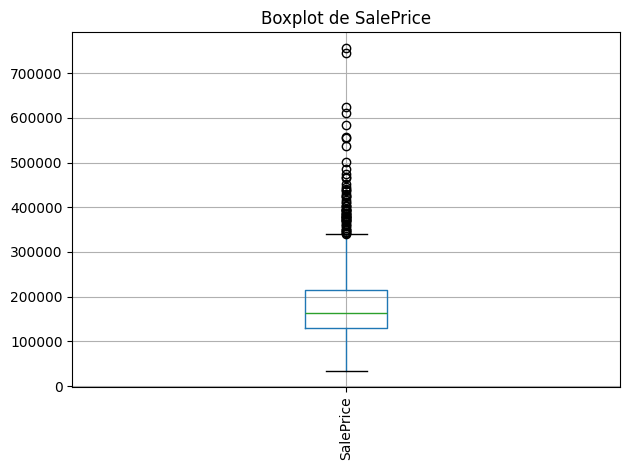

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [81]:
# En el grafico boxplot vimos 2 columnas con datos outliers y revisaremos ambas en detalle
# Análisis de SalePrice

train.boxplot(column=['SalePrice'])
plt.title('Boxplot de SalePrice')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

train["SalePrice"].describe()

In [82]:
# Calculamos el IQR y obtenemos el largo del bigote superior
Q1 = train["SalePrice"].quantile(0.25)
Q3 = train["SalePrice"].quantile(0.75)
IQR_SalePrice = Q3 - Q1

bigote_SalePrice = train["SalePrice"].quantile(0.75) + 1.5 * IQR_SalePrice
print(f'El valor de IQR de SalePrice es: {IQR_SalePrice}')
print(f'El largo del bigote de SalePrice es: {bigote_SalePrice}')

El valor de IQR de SalePrice es: 84025.0
El largo del bigote de SalePrice es: 340037.5


In [83]:
# Contamos la cantidad de registros cuyo SalePrice es mayor al largo del bigote
train[train["SalePrice"] > bigote_SalePrice].shape

(61, 81)

In [84]:
# Buscamos registros cuyo LotArea es mayor a bigote_LotArea y que SalePrice sea mayor bigote_SalePrice
train[(train["LotArea"] > bigote_LotArea) & (train["SalePrice"] > bigote_SalePrice)]


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
53,54,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000
185,186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
313,314,20,RL,150.0,215245,Pave,NaN,IR3,Low,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,375000
349,350,60,RL,56.0,20431,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,New,Partial,437154
661,662,60,RL,52.0,46589,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,402000
664,665,20,RL,49.0,20896,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2006,New,Partial,423000
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
769,770,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000


Podriamos pensar que estos registros se podría eliminar, que ya que tiene registros atipicos en ambas columnas que son las más llamativas

In [85]:
# eliminar registros cuyo LotArea es mayor a bigote_LotArea y que SalePrice sea mayor bigote_SalePrice
train = train[(train["LotArea"] <= bigote_LotArea) & (train["SalePrice"] <= bigote_SalePrice)]


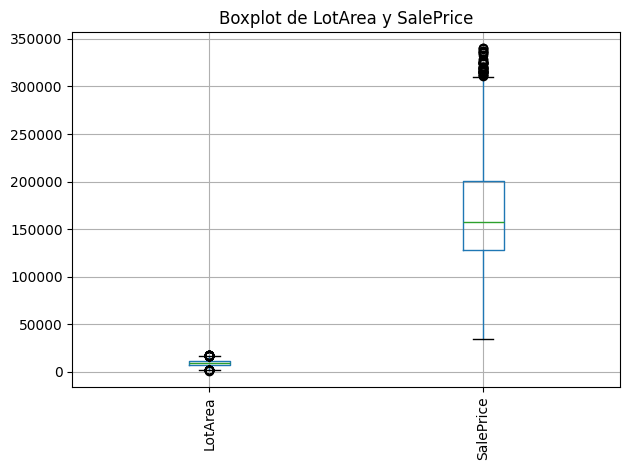

In [86]:
# Análisis de LotArea y SalePrice

train.boxplot(column=['LotArea', 'SalePrice'])
plt.title('Boxplot de LotArea y SalePrice')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Al parecer, estos registro eran los que tenían una mayor diferencia en ambas columnas. En el caso del SalePrice se aprecian outliers, pero no lejos del valor del largo del bigote y por tratarse de precios de viviendas, podrían ser valores correctos, por lo que se dejarán como están actualmente.

Como el dataframe tiene 1460 registros, borraré todos las columnas cuya cantidad de nulos supere los 400, pues al imputarle valor, podría cesgar la calidad de mi modelo

Las columnas eliminadas son: "Alley", "MasVnrType", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"

In [87]:
# Select columns, excluding those with more than 400 missing values that were dropped earlier
df = train[['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'SalePrice']].copy() # Create a copy to avoid SettingWithCopyWarning

In [88]:
# actualizo valores nulo por la media en variables numericas
df['LotFrontage'].fillna(df['LotFrontage'].mean(), inplace=True)
df['MasVnrArea'].fillna(df['MasVnrArea'].mean(), inplace=True)
df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean(), inplace=True)

# actualizo valores mulos por la moda en variables categóricas
df['Electrical'].fillna(df['Electrical'].mode()[0], inplace=True)
df['GarageType'].fillna(df['GarageType'].mode()[0], inplace=True)
df['GarageFinish'].fillna(df['GarageFinish'].mode()[0], inplace=True)
df['GarageQual'].fillna(df['GarageQual'].mode()[0], inplace=True)
df['GarageCond'].fillna(df['GarageCond'].mode()[0], inplace=True)
df['BsmtQual'].fillna(df['BsmtQual'].mode()[0], inplace=True)
df['BsmtCond'].fillna(df['BsmtCond'].mode()[0], inplace=True)
df['BsmtExposure'].fillna(df['BsmtExposure'].mode()[0], inplace=True)
df['BsmtFinType1'].fillna(df['BsmtFinType1'].mode()[0], inplace=True)
df['BsmtFinType2'].fillna(df['BsmtFinType2'].mode()[0], inplace=True)
df['MSZoning'].fillna(df['MSZoning'].mode()[0], inplace=True)
df['Utilities'].fillna(df['Utilities'].mode()[0], inplace=True)
df['GarageCars'].fillna(df['GarageCars'].mode()[0], inplace=True)
df['GarageArea'].fillna(df['GarageArea'].mode()[0], inplace=True)
df['BsmtFullBath'].fillna(df['BsmtFullBath'].mode()[0], inplace=True)
df['BsmtHalfBath'].fillna(df['BsmtHalfBath'].mode()[0], inplace=True)
df['MasVnrArea'].fillna(df['MasVnrArea'].mode()[0], inplace=True)
df['BsmtFinSF1'].fillna(df['BsmtFinSF1'].mode()[0], inplace=True)
df['BsmtFinSF2'].fillna(df['BsmtFinSF2'].mode()[0], inplace=True)
df['BsmtUnfSF'].fillna(df['BsmtUnfSF'].mode()[0], inplace=True)
df['TotalBsmtSF'].fillna(df['TotalBsmtSF'].mode()[0], inplace=True)
df['GarageYrBlt'].fillna(df['GarageYrBlt'].mode()[0], inplace=True)
df['MasVnrArea'].fillna(df['MasVnrArea'].mode()[0], inplace=True)

df['GarageYrBlt'].fillna(df['GarageYrBlt'].mode()[0], inplace=True)
df['GarageArea'].fillna(df['GarageArea'].mode()[0], inplace=True)
df['GarageCars'].fillna(df['GarageCars'].mode()[0], inplace=True)
df['GarageArea'].fillna(df['GarageArea'].mode()[0], inplace=True)
df['GarageYrBlt'].fillna(df['GarageYrBlt'].mode()[0], inplace=True)




/tmp/ipython-input-88-473550740.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LotFrontage'].fillna(df['LotFrontage'].mean(), inplace=True)
/tmp/ipython-input-88-473550740.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [89]:
# Comprobamos que no existen valores nulos
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


**4. Preprocesamiento de Datos:**

- Transformar las columnas según sea necesario (codificación de variables categóricas, escalado de características numéricas).
- Dividir el dataset en conjuntos de entrenamiento y prueba.

In [90]:
# buscar sólo las columnas numericas que tienen mayor correlacion con SalePrice

# Seleccionar solo las columnas numéricas
df_numeric = df.select_dtypes(include=['number'])

# Calcular la correlación con la columna 'SalePrice' y ordeno en forma descendente
correlation = df_numeric.corr()['SalePrice'].abs().sort_values(ascending=False)

# Obtener las 15 columnas con mayor correlación
top_15 = correlation.drop('SalePrice').head(15)

# Mostrar el resultado
print("Top 15 columnas más correlacionadas con 'SalePrice':")
print(top_15)



Top 15 columnas más correlacionadas con 'SalePrice':
OverallQual     0.803484
GrLivArea       0.693899
GarageCars      0.643375
GarageArea      0.637886
TotalBsmtSF     0.591718
YearBuilt       0.591508
FullBath        0.587798
1stFlrSF        0.558061
YearRemodAdd    0.555769
GarageYrBlt     0.511704
TotRmsAbvGrd    0.479341
Fireplaces      0.444158
LotArea         0.393894
MasVnrArea      0.364782
OpenPorchSF     0.339734
Name: SalePrice, dtype: float64


In [91]:
# tomaremos esas columnas para hecer nuestro modelo, dejando de lado las columnas que tienen m enos correlación con la variable objetivo
# Tenemos la lista de las 15 columnas más correlacionadas
top_15_columns = top_15.index.tolist()

# Crear un nuevo DataFrame con esas columnas más 'SalePrice'
df_top_15 = df[top_15_columns + ['SalePrice']]


In [92]:
# Miramos el DF que utilizaré para validar modelos
df_top_15.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1341 entries, 0 to 1459
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   1341 non-null   int64  
 1   GrLivArea     1341 non-null   int64  
 2   GarageCars    1341 non-null   int64  
 3   GarageArea    1341 non-null   int64  
 4   TotalBsmtSF   1341 non-null   int64  
 5   YearBuilt     1341 non-null   int64  
 6   FullBath      1341 non-null   int64  
 7   1stFlrSF      1341 non-null   int64  
 8   YearRemodAdd  1341 non-null   int64  
 9   GarageYrBlt   1341 non-null   float64
 10  TotRmsAbvGrd  1341 non-null   int64  
 11  Fireplaces    1341 non-null   int64  
 12  LotArea       1341 non-null   int64  
 13  MasVnrArea    1341 non-null   float64
 14  OpenPorchSF   1341 non-null   int64  
 15  SalePrice     1341 non-null   int64  
dtypes: float64(2), int64(14)
memory usage: 178.1 KB


In [93]:
X = df_top_15.drop('SalePrice', axis=1)
y = df_top_15['SalePrice']

In [94]:
#  Obtenemos listado de columnas para Tranformar
num_cols = X.columns.values
num_cols

array(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', 'YearBuilt', 'FullBath', '1stFlrSF', 'YearRemodAdd',
       'GarageYrBlt', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea',
       'MasVnrArea', 'OpenPorchSF'], dtype=object)

In [95]:
# Dividimos dataframe en training y testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Implementación de Modelos y Benchmark:**

- Entrenar y evaluar al menos cinco modelos diferentes, como Regresión Logística, K-Nearest Neighbors (KNN), Árbol de Decisión, XGBoost y LightGBM.
- Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.
- Optimizar los hiperparámetros de los modelos seleccionados utilizando GridSearchCV o RandomizedSearchCV.
- Comparar el rendimiento de los modelos utilizando métricas adecuadas.

Entrenar y evaluar al menos cinco modelos diferentes, como Regresión Logística, K-Nearest Neighbors (KNN), Árbol de Decisión, XGBoost y LightGBM.

Utilizaré:

- KNN
- Arbol de Decisión
- LightGBM
- XGBRegressor
- SVM Regressor



K-Neighbord

In [96]:
# Definir transformadores para KNN.
preprocessor_knn = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
])

In [97]:
# Crear pipeline para KNN.
pipeline_knn = Pipeline(steps=[
    ("preprocessing", preprocessor_knn),
    ("model", KNeighborsRegressor())
])

Arbol de Decisión

In [98]:
# Definir transformadores para Tree.
preprocessor_tree = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
])

In [99]:
# Crear pipeline para Tree.
pipeline_tree = Pipeline(steps=[
    ("preprocessing", preprocessor_tree),
    ("model", DecisionTreeRegressor())
])

LightGBM

In [100]:
# Definir transformadores para LGBM.
preprocessor_lgbm = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
])

In [101]:
# Crear pipeline para Tree.
pipeline_lgbm = Pipeline(steps=[
    ("preprocessing", preprocessor_lgbm),
    ("model", LGBMRegressor())
])

XGBRegressor

In [102]:
# Definir transformadores para XGBRegressor.
preprocessor_xgb = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
])

In [103]:
# Crear pipeline para XGBRegressor.
pipeline_xgb = Pipeline(steps=[
    ("preprocessing", preprocessor_tree),
    ("model", XGBRegressor())
])

SVM Regressor

In [104]:
# Definir transformadores para XGBRegressor.
preprocessor_svm = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
])

In [105]:
# Crear pipeline para XGBRegressor.
pipeline_svm = Pipeline(steps=[
    ("preprocessing", preprocessor_tree),
    ("model", SVR())
])

**Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos**

KNN

In [106]:
# usamos cross_val_score para entrenar el modelo
cv_results = cross_val_score(pipeline_knn, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [107]:
# Desplegamos resultado de neg_mean_squared_error
cv_results.mean()

np.float64(-617649651.0229414)

Arbol de Decision

In [108]:
# usamos cross_val_score para entrenar el modelo
cv_results = cross_val_score(pipeline_tree, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [109]:
# Desplegamos resultado de neg_mean_squared_error
cv_results.mean()

np.float64(-990187864.981139)

LightGBM

In [110]:
# usamos cross_val_score para entrenar el modelo
cv_results = cross_val_score(pipeline_lgbm, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [111]:
# Desplegamos resultado de neg_mean_squared_error
cv_results.mean()

np.float64(-527800711.5088517)

XGBRegressor

In [112]:
# usamos cross_val_score para entrenar el modelo
cv_results = cross_val_score(pipeline_xgb, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [113]:
# Desplegamos resultado de neg_mean_squared_error
cv_results.mean()

np.float64(-580145849.6)

SVM Regressor

In [114]:
# usamos cross_val_score para entrenar el modelo
cv_results = cross_val_score(pipeline_svm, X_train, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [115]:
# Desplegamos resultado de neg_mean_squared_error
cv_results.mean()

np.float64(-3605397115.329666)

**Optimizar los hiperparámetros de los modelos seleccionados utilizando GridSearchCV o RandomizedSearchCV.**

KNN

In [116]:
# Optimizacion de hiperparametros de KNN
knn_params = {
    "model__n_neighbors": [3, 5, 7, 10, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_grid = GridSearchCV(pipeline_knn, knn_params, cv=3, scoring="r2")
knn_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         array(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', 'YearBuilt', 'FullBath', '1stFlrSF', 'YearRemodAdd',
       'GarageYrBlt', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea',
       'MasVnrArea', 'OpenPorchSF'], dtype=object))])),
                                       ('model', KNeighborsRegressor())]),
             param_grid={'model__n_neighbors': [3, 5, 7, 10, 15],
                         'model__p': [1, 2],
                         'model__weights': ['uniform', 'distance']},
             scoring='r2')

In [117]:
# Evaluación KNN
knn_best = knn_grid.best_estimator_
y_pred_knn = knn_best.predict(X_test)

print("K-Neighnors")
print("Mejores parámetros:", knn_grid.best_params_)
print("R2:", r2_score(y_test, y_pred_knn))

K-Neighnors
Mejores parámetros: {'model__n_neighbors': 10, 'model__p': 1, 'model__weights': 'distance'}
R2: 0.8879815371043338


In [118]:
# K-Neighnors
# Mejores parámetros: {'model__n_neighbors': 10, 'model__p': 1, 'model__weights': 'distance'}
# R2: 0.8881035528897431

# Uso los mejores parametros
knn_best = knn_grid.best_estimator_
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)
print("K-Neighbors")
r2_knn = r2_score(y_test, y_pred_knn)
print(f"R2 Score: {r2_knn:.2f}")

K-Neighbors
R2 Score: 0.89


Arbol de Decisión

In [119]:
# Optimizacion de hiperparametros Tree
tree_params = {
    "model__criterion": ["squared_error", "absolute_error", "poisson"],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

tree_grid = GridSearchCV(pipeline_tree, tree_params, cv=3, scoring="r2")
tree_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         array(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', 'YearBuilt', 'FullBath', '1stFlrSF', 'YearRemodAdd',
       'GarageYrBlt', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea',
       'MasVnrArea', 'OpenPorchSF'], dtype=object))])),
                                       ('model', DecisionTreeRegressor())]),
             param_grid={'model__criterion': ['squared_error', 'absolute_error',
                                              'poisson'],
                         'model__max_depth': [5, 10, 15],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='r2')

In [120]:
# Evaluación Tree
tree_best = tree_grid.best_estimator_
y_pred_tree = tree_best.predict(X_test)

print("Arbol de Decisión")
print("Mejores parámetros:", tree_grid.best_params_)
print("R2:", r2_score(y_test, y_pred_tree))

Arbol de Decisión
Mejores parámetros: {'model__criterion': 'squared_error', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
R2: 0.814595937463679


In [121]:
# Arbol de Decisión
# Mejores parámetros: {'model__criterion': 'poisson', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
# R2: 0.8052213405022732

# Uso los mejores parametros
tree_best = tree_grid.best_estimator_
tree_best.fit(X_train, y_train)
y_pred_tree = tree_best.predict(X_test)
print("Arbol de Decisión")
r2_tree = r2_score(y_test, y_pred_tree)
print(f"R2 Score: {r2_tree:.2f}")

Arbol de Decisión
R2 Score: 0.81


LightGBM

In [122]:
# Optimizacion de hiperparametros LGBM
lgbm_params = {
    "model__boosting_type": ["gbdt", "dart", "rf"],
    "model__max_depth": [5, 10, 15],
    "model__num_leaves": [20, 30, 40],
}

lgbm_grid = GridSearchCV(pipeline_lgbm, lgbm_params, cv=3, scoring="r2")
lgbm_grid.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1517
[LightGBM] [Info] Number of data points in the train set: 714, number of used features: 15
[LightGBM] [Info] Start training from score 170022.296919
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1490
[LightGBM] [Info] Number of data points in the train set: 715, number of used features: 15
[LightGBM] [Info] Start training from score 168654.166434
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1762
[LightGBM] [Info] Number of data points in the train set: 1072, number of used features: 15
[LightGBM] [Info] Start training from score 169117.279851
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         array(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', 'YearBuilt', 'FullBath', '1stFlrSF', 'YearRemodAdd',
       'GarageYrBlt', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea',
       'MasVnrArea', 'OpenPorchSF'], dtype=object))])),
                                       ('model', LGBMRegressor())]),
             param_grid={'model__boosting_type': ['gbdt', 'dart', 'rf'],
                         'model__max_depth': [5, 10, 15],
                         'model__num_leaves': [20, 30, 40]},
             scoring='r2')

In [123]:
# Evaluación LGBM
lgbm_best = lgbm_grid.best_estimator_
y_pred_lgbm = lgbm_best.predict(X_test)

print("LigthGBM")
print("Mejores parámetros:", lgbm_grid.best_params_)
print("R2:", r2_score(y_test, y_pred_lgbm))

LigthGBM
Mejores parámetros: {'model__boosting_type': 'gbdt', 'model__max_depth': 5, 'model__num_leaves': 20}
R2: 0.8984133356597906


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [124]:
# LigthGBM
# Mejores parámetros: {'model__boosting_type': 'gbdt', 'model__max_depth': 5, 'model__num_leaves': 30}
# R2: 0.9012405178534988

# Uso los mejores parametros
lgbm_best = lgbm_grid.best_estimator_
lgbm_best.fit(X_train, y_train)
y_pred_lgbm = lgbm_best.predict(X_test)
print("LigthGBM")
r2_lgbm = r2_score(y_test, y_pred_lgbm)
print(f"R2 Score: {r2_lgbm:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1762
[LightGBM] [Info] Number of data points in the train set: 1072, number of used features: 15
[LightGBM] [Info] Start training from score 169117.279851
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


XGBRegressor

In [125]:
# Optimizacion de hiperparametros XGBRegressor

xgb_params = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [5, 10, 15],
    "model__booster": ["gbtree", "dart"],
 #   "model__learning_rate": [0.01, 0.1, 0.2],
 #   "model__subsample": [0.8, 1.0],
}

xgb_grid = GridSearchCV(pipeline_xgb, xgb_params, cv=3, scoring="r2")
xgb_grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         array(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', 'YearBuilt', 'FullBath', '1stFlrSF', 'YearRemodAdd',
       'GarageYrBlt', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea',
       'MasVnrArea', 'OpenPorchSF'], dtype=object))])),
                                       ('model',
                                        XGBR...
                                                     max_cat_to_onehot=None,
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None,
                                                     random_state=None, ...))]),
             param_grid={'model__booster': ['gbtree', 'dart'],
                         'model__max_depth': [5, 10, 15],
                         'model__n_estimators': [50, 100, 150]},
             scoring='r2')

In [126]:
# Evaluación XGBRegressor
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

print("XGBRegressor")
print("Mejores parámetros:", xgb_grid.best_params_)
print("R2:", r2_score(y_test, y_pred_xgb))

XGBRegressor
Mejores parámetros: {'model__booster': 'gbtree', 'model__max_depth': 5, 'model__n_estimators': 50}
R2: 0.8847413659095764


In [127]:
# XGBRegressor
# Mejores parámetros: {'model__booster': 'gbtree', 'model__max_depth': 5, 'model__n_estimators': 50}
# R2: 0.8847413659095764

# Uso los mejores parametros
xgb_best = xgb_grid.best_estimator_
xgb_best.fit(X_train, y_train)
y_pred_xgb = xgb_best.predict(X_test)
print("XGBRegressor")
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"R2 Score: {r2_xgb:.2f}")

XGBRegressor
R2 Score: 0.88


SVM Regressor

In [128]:
# Optimizacion de hiperparametros SVM Regressor

svm_params = {
    "model__kernel": ["linear", "poly", "rbf", "sigmoid", "precomputed"],
    "model__C": [1.0, 2.0, 3.0, 4.0],
    "model__gamma": ["scale", "auto"],
    "model__degree": [2, 3, 4],

}

svm_grid = GridSearchCV(pipeline_svm, svm_params, cv=3, scoring="r2")
svm_grid.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
72 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         array(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', 'YearBuilt', 'FullBath', '1stFlrSF', 'YearRemodAdd',
       'GarageYrBlt', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea',
       'MasVnrArea', 'OpenPorchSF'], dtype=object))])),
                                       ('model', SVR())]),
             param_grid={'model__C': [1.0, 2.0, 3.0, 4.0],
                         'model__degree': [2, 3, 4],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid',
                                           'precomputed']},
             scoring='r2')

In [129]:
# Evaluación XGBRegressor
svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test)

print("SVM Regressor")
print("Mejores parámetros:", svm_grid.best_params_)
print("R2:", r2_score(y_test, y_pred_svm))

SVM Regressor
Mejores parámetros: {'model__C': 4.0, 'model__degree': 2, 'model__gamma': 'scale', 'model__kernel': 'linear'}
R2: 0.45217879402761263


In [130]:
# SVM Regressor
# Mejores parámetros: {'model__C': 4.0, 'model__degree': 2, 'model__gamma': 'scale', 'model__kernel': 'linear'}
# R2: 0.45217879402761263

# Uso los mejores parametros
svm_best = svm_grid.best_estimator_
svm_best.fit(X_train, y_train)
y_pred_svm = svm_best.predict(X_test)
print("SVM Regressor")
r2_svm = r2_score(y_test, y_pred_xgb)
print(f"R2 Score: {r2_svm:.2f}")

SVM Regressor
R2 Score: 0.88


**Comparar el rendimiento de los modelos utilizando métricas adecuadas.**

In [131]:
#Imprimo R2 de los modelos
print(f"R2 KNN: {r2_knn:.2f}")
print(f"R2 Tree: {r2_tree:.2f}")
print(f"R2 LGBM: {r2_lgbm:.2f}")
print(f"R2 XGBRegressor: {r2_xgb:.2f}")
print(f"R2 SVM Regressor: {r2_svm:.2f}")

R2 KNN: 0.89
R2 Tree: 0.81
R2 LGBM: 0.90
R2 XGBRegressor: 0.88
R2 SVM Regressor: 0.88


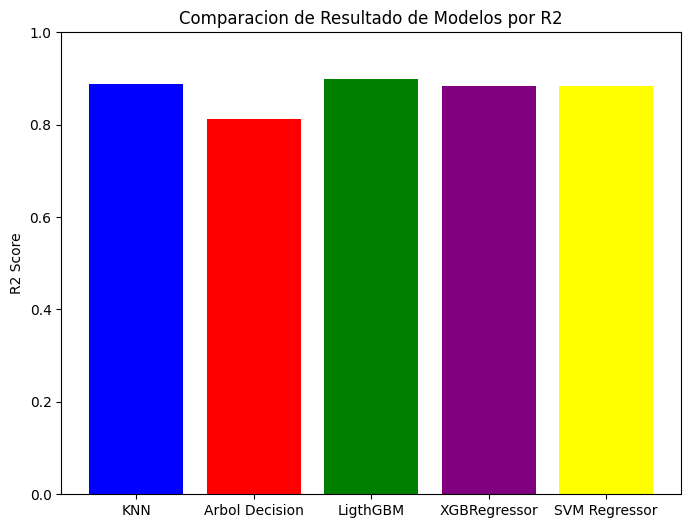

In [132]:
# grafico de barra para comparar los resultados
models = ['KNN', 'Arbol Decision', 'LigthGBM', 'XGBRegressor', 'SVM Regressor']

mse_values = [r2_knn, r2_tree, r2_lgbm, r2_xgb, r2_svm]


plt.figure(figsize=(8, 6))
plt.bar(models, mse_values, color=['blue', 'red', 'green', 'purple', 'yellow'])
plt.ylim(0, 1)
plt.ylabel('R2 Score')
plt.title('Comparacion de Resultado de Modelos por R2')
plt.show()


Este gráfico de barras muestra una comparación del rendimiento de diferentes modelos de regresión basándose en la métrica R
2
  (Coeficiente de Determinación).

El gráfico muestra que los modelos basados en Gradient Boosting (LightGBM y XGBRegressor), junto con KNN, son los que mejor rendimiento tienen para este problema de regresión, ya que todos alcanzan valores de R
2
  muy altos, cercanos a 0.90 o más. El Árbol de Decisión individual, si no está optimizado o es demasiado simple, parece tener un rendimiento inferior en comparación con los otros algoritmos.

  Si tomamos como resultados los R2, el que obtiene la mayor puntuación es LightGBM con un 90%